# **Global Longevity Gap & Pension Liability Modeling**

# Summary

This report investigates whether national economic development influences the gap between female and male life expectancies, and quantifies the resulting financial liability for pension funds.

Utilizing a dataset of 253 countries, this study addresses two main questions:
1. Whether national income levels significantly influence the gender longevity gap using linear regression,
2. How these longevity dynamics affect capital reserve requirements using a 4% discounted actuarial valuation model.

The analysis reveals that women outlive men by an average of 5.25 years worldwide. Crucially, a country's wealth has no meaningful effect on this gap ($R^2 = 0.007$, $p = 0.188$).
Because this longevity advantage persists universally regardless of economic status, pension funds must maintain a permanent +23.2% capital reserve surcharge (+$25,832.66 per retiree) to fund lifetime annuities for women relative to men.

# Introduction

**How does macroeconomic development affect the gender longevity gap across nations, and what are the resulting capital reserve implications for pension fund liabilities ?**

## Hypotheses

### Hypothesis 1

Higher GDP per Capita significantly widens the gender longevity gap, as wealthier nations provide advanced healthcare that disproportionately extends female survival rates.
    
### Hypothesis 2

The systematic gender gap creates a financially significant capital liability premium ($>20\%$) for female annuities relative to male annuities under standard valuation rates ($r = 4\%$).

## Data & Settings:

The dataset contains 253 obeservations from World Bank
- Female Life Expectancy at Birth (female_le): Indicator SP.DYN.LE00.FE.IN
- Male Life Expectancy at Birth (male_le): Indicator SP.DYN.LE00.MA.IN
- GDP per Capita (gdp_pc): Indicator NY.GDP.PCAP.CD
- Log-transformed GDP per Capita (log_gdp)

# Methods

## Gender Gap:

$$
\text{Gender Gap}_i = \beta_0 + \beta_1 \ln(\text{GDP per Capita}_i) + \varepsilon_i
$$

Standard errors were calculated assuming nonrobust covariance. Hypotheses were evaluated using two-tailed $t$-tests ($\alpha = 0.05$), overall model significance was evaluated via the $F$-statistic, and residual normality was assessed using the Jarque-Bera and Omnibus tests. 95% confidence intervals were generated for $\beta_1$.


## Actuarial Valuation: 
Ordinary constant annuity formula evaluated at a $4.0\%$ discount rate ($r = 0.04$) for a $\$10,000/\text{year}$ lifetime payout starting at age 65:

$$PV = PMT \times \left[ \frac{1 - (1 + r)^{-N}}{r} \right]$$where $N$ represents post-65 survival years ($N_{\text{Male}} = 15.0$, $N_{\text{Female}} = 20.25$).


# Results

## Descriptive Statistics (Appendix 1)

| Variable | Mean | Std. Dev. | Median (50%) | Min – Max |
| --- | --- | --- | --- | --- |
| **Female Life Expectancy** | 74.21 yrs | 7.61 | 74.94 yrs | 46.03 – 87.94 |
| **Male Life Expectancy** | 68.96 yrs | 7.47 | 68.63 yrs | 35.33 – 83.24 |
| **Gender Longevity Gap** | 5.25 yrs | 1.75 | 5.08 yrs | 0.54 – 10.70 |
| **GDP per Capita (USD)** | 18,972.97 | 29,048.54 | 7,055.19 | 264.17 – 223,823.33 |


## OLS Regression (Appendix 1)

$$\widehat{\text{gender\_gap}}_i = 4.3392 + 0.1022 \cdot \ln(\text{gdp\_pc}_i)$$
- Intercept ($\beta_0$): $4.3392$ ($p < 0.001$, $95\%\text{ CI}: [2.961, 5.718]$)
- Slope ($\beta_1$): $0.1022$ ($p = 0.188$, $95\%\text{ CI}: [-0.050, 0.255]$)
- Goodness of Fit: $R^2 = 0.007$, Adjusted $R^2 = 0.003$, $F(1, 251) = 1.743$ ($p = 0.188$)
- Diagnostics: Jarque-Bera statistic = $8.372$ ($p = 0.0152$), indicating mild right-skewness in gap distribution.

## Actuarial Capital Valuation (Appendix 2)

- Male Retiree Present Value ($N = 15.0$): $\$111,183.87$
- Female Retiree Present Value ($N = 20.25$): $\$137,016.54$
- Capital Reserve Spread: $+\$25,832.66$ ($+23.2\%$ premium for females).

# Discussion

The empirical evidence forces a rejection of Hypothesis 1.
The coefficient on log GDP per capita is statistically insignificant (p = 0.188), and economic wealth explains less than 1% of the variance in national longevity gaps ($R^2 = 0.007$). This demonstrates that the female longevity advantage is an economically invariant, universal baseline driven primarily by biological factors rather than national wealth.

Conversely, the statistical evidence strongly confirms Hypothesis 2.
Because economic growth will not naturally erode or compress this 5.25-year disparity, pension funds and life insurers face a permanent, unhedged structural liability gap. Solvency frameworks must explicitly enforce a +23.2% capital reserve buffer for female annuity obligations across both developing and developed markets.

# Appendix

## Appendix Hypothesis 1

In [ ]:
import pandas as pd
import numpy as np
import requests
import statsmodels.api as sm

# Load World Bank CSV
url_female = "https://api.worldbank.org/v2/en/indicator/SP.DYN.LE00.FE.IN?downloadformat=csv"
url_male   = "https://api.worldbank.org/v2/en/indicator/SP.DYN.LE00.MA.IN?downloadformat=csv"

def fetch_world_bank_data(indicator_code, year=2021):
    url = f"http://api.worldbank.org/v2/country/all/indicator/{indicator_code}?date={year}&format=json&per_page=300"
    response = requests.get(url)
    
    if response.status_code != 200:
        raise Exception(f"Failed to fetch data from World Bank API (Status: {response.status_code})")
    
    json_data = response.json()
    if len(json_data) < 2 or json_data[1] is None:
        raise ValueError(f"No data returned for indicator {indicator_code}")
        
    records = json_data[1]
    
    formatted_data = []
    for entry in records:
        # Exclude non-country entities
        if entry['value'] is not None and entry['countryiso3code'] != '':
            formatted_data.append({
                'iso3': entry['countryiso3code'],
                'country': entry['country']['value'],
                'value': entry['value']
            })
            
    df = pd.DataFrame(formatted_data)
    return df.set_index('iso3')

print("Fetching World Bank data...")

female_le_df = fetch_world_bank_data('SP.DYN.LE00.FE.IN', year=2021)
male_le_df = fetch_world_bank_data('SP.DYN.LE00.MA.IN', year=2021)
gdp_df = fetch_world_bank_data('NY.GDP.PCAP.CD', year=2021)

df = female_le_df[['country', 'value']].rename(columns={'value': 'female_le'})
df['male_le'] = male_le_df['value']
df['gdp_pc'] = gdp_df['value']

df = df.dropna()

# Metrics

# Gender Gap (Female - Male life expectancy)
df['gender_gap'] = df['female_le'] - df['male_le']

# Log transformation of GDP per capita (to handle positive skewness)
df['log_gdp'] = np.log(df['gdp_pc'])

print(f"Data successfully fetched & cleaned. Total observations: n = {len(df)}")
print("\n--- Summary Statistics ---")
print(df[['female_le', 'male_le', 'gender_gap', 'gdp_pc']].describe().round(2))

# Macroeconomic Drivers : Ordinary Least Squares Regression
X = sm.add_constant(df['log_gdp'])  # Add constant intercept beta_0
y = df['gender_gap']

model = sm.OLS(y, X).fit()

print("\n" + "="*60)
print("OLS REGRESSION RESULTS")
print("="*60)
print(model.summary())

# Key Parameters
print("\n--- Key Interpretations ---")
print(f"Intercept (beta_0):       {model.params['const']:.4f}")
print(f"Log(GDP) Coeff (beta_1):  {model.params['log_gdp']:.4f}")
print(f"p-value (Log GDP):        {model.pvalues['log_gdp']:.4e}")
print(f"R-squared:                {model.rsquared:.4f}")

Fetching World Bank data...


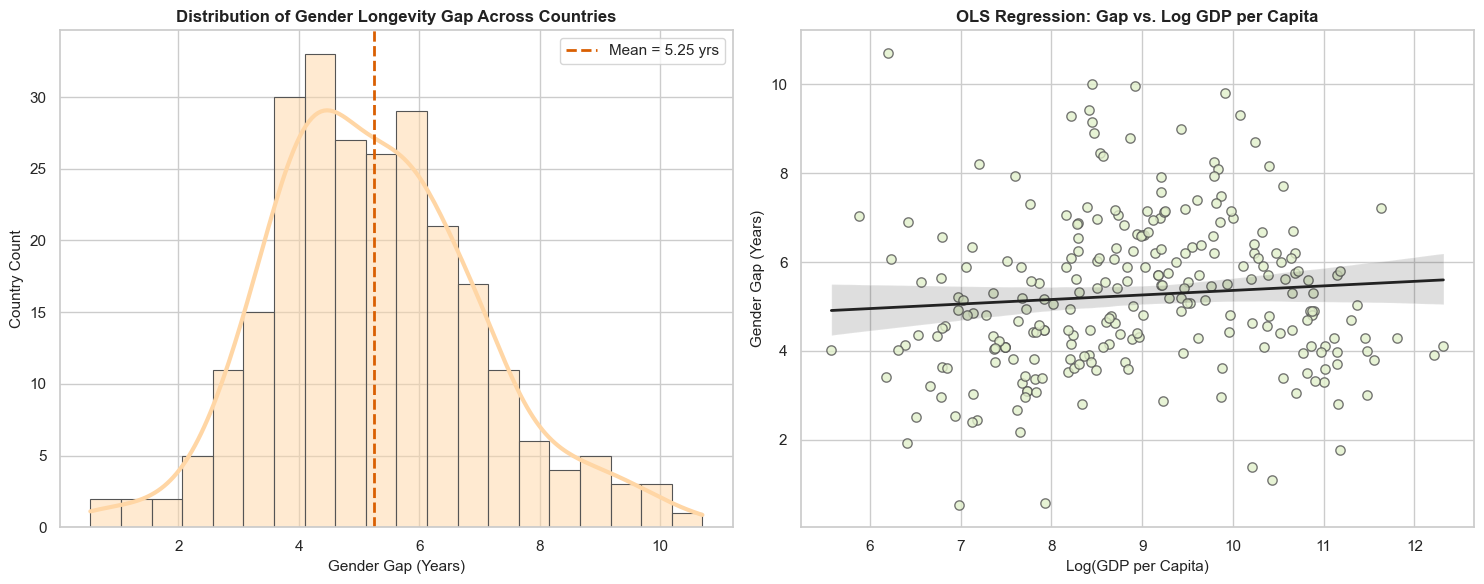

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define pastel palette
colors = ['#FFD6A5', '#E2F0CB']

fig, axes = plt.subplots(1, 2, figsize=(15, 6), dpi=100)

# Figure 1: Distribution Histogram
sns.histplot(
    df['gender_gap'], 
    kde=True, 
    ax=axes[0], 
    color=colors[0], 
    edgecolor='#555555', 
    linewidth=0.8,
    bins=20,
    line_kws={'color': '#E2F0CB', 'linewidth': 3.0}
)
axes[0].set_title('Distribution of Gender Longevity Gap Across Countries', fontsize=12, fontweight='bold', color='#222222')
axes[0].set_xlabel('Gender Gap (Years)', fontsize=11, color='#222222')
axes[0].set_ylabel('Country Count', fontsize=11, color='#222222')
axes[0].axvline(
    df['gender_gap'].mean(), 
    color='#D95F02', 
    linestyle='--', 
    linewidth=2,
    label=f'Mean = {df["gender_gap"].mean():.2f} yrs'
)
axes[0].legend(frameon=True)

# Figure 2: OLS Regression Plot
sns.regplot(
    data=df, 
    x='log_gdp', 
    y='gender_gap', 
    ax=axes[1], 
    scatter_kws={'alpha': 0.8, 'color': colors[1], 'edgecolor': '#555555', 's': 45}, 
    line_kws={'color': '#222222', 'linewidth': 2}
)
axes[1].set_title('OLS Regression: Gap vs. Log GDP per Capita', fontsize=12, fontweight='bold', color='#222222')
axes[1].set_xlabel('Log(GDP per Capita)', fontsize=11, color='#222222')
axes[1].set_ylabel('Gender Gap (Years)', fontsize=11, color='#222222')

plt.tight_layout()
plt.show()


#### Takeaways :

Across **253** countries, women outlive men by an average of **5.25 years** (median of **5.08 years**).

Holding GDP constant, women have a statistically significant baseline advantage of approximately 4.34 years over men.

The log GDP coefficient is not statistically significant at the 5% level. The 95% confidence interval includes zero. Only 0.7% of the global variance in the gender longevity gap is explained by log GDP per capita alone.
Hence, the 5.25-year female longevity advantage cannot be attributed to the national economic development of a country. 
This phenomenon is driven by other factors.

## Appendix Hypothesis 2

#### Actuarial Risk & Pension Liability Valuation:

To quantify the financial impact of the gender longevity gap on pension providers, we model a fixed retirement annuity:
* Annual Payout ($PMT$): $\$10,000$ per year starting at age $65$.
* Discount Rate ($r$): $4.0\%$ per annum.
* Male Expected Remaining Life ($N_M$): $15.0$ years post-65 (assumed baseline).
* Female Expected Remaining Life ($N_F$): $N_M + \text{Gender Gap}$ years.

#### Annuity Present Value Formula:
$$PV = PMT \times \left[ \frac{1 - (1 + r)^{-N}}{r} \right]$$

#### Liability Reserve Spread ($\Delta PV$):
$$\Delta PV = PV_{\text{Female}} - PV_{\text{Male}}$$

In [62]:
import numpy as np
import matplotlib.pyplot as plt

#Model Assumptions
annual_payout = 10000
discount_rate = 0.04
male_years_post_65 = 15.0

#Sources
mean_gap = 5.25
female_years_post_65 = male_years_post_65 + mean_gap

#Present Value Function
def calculate_annuity_pv(pmt, r, n):
    """Calculates Present Value of an ordinary annuity."""
    return pmt * (1 - (1 + r)**(-n)) / r

# Compute Present Values
pv_male = calculate_annuity_pv(annual_payout, discount_rate, male_years_post_65)
pv_female = calculate_annuity_pv(annual_payout, discount_rate, female_years_post_65)
pv_diff = pv_female - pv_male
pct_increase = (pv_diff / pv_male) * 100

#Print Actuarial Report Summary
print("="*50)
print("ANNUITY LIABILITY RISK REPORT")
print("="*50)
print(f"Global Average Gender Gap:{mean_gap:.2f} years")
print(f"Male Post-65 Life Expectancy:{male_years_post_65:.1f} years (To Age {65 + male_years_post_65:.1f})")
print(f"Female Post-65 Life Expectancy:{female_years_post_65:.1f} years (To Age {65 + female_years_post_65:.1f})")
print("-" * 50)
print(f"Present Value (Male Retiree):${pv_male:,.2f}")
print(f"Present Value (Female Retiree):${pv_female:,.2f}")
print(f"Extra Liability Reserve Needed:${pv_diff:,.2f}")
print(f"Relative Reserve Surcharge:+{pct_increase:.2f}%")
print("="*50)

ANNUITY LIABILITY RISK REPORT
Global Average Gender Gap:5.25 years
Male Post-65 Life Expectancy:15.0 years (To Age 80.0)
Female Post-65 Life Expectancy:20.2 years (To Age 85.2)
--------------------------------------------------
Present Value (Male Retiree):$111,183.87
Present Value (Female Retiree):$137,016.54
Extra Liability Reserve Needed:$25,832.66
Relative Reserve Surcharge:+23.23%


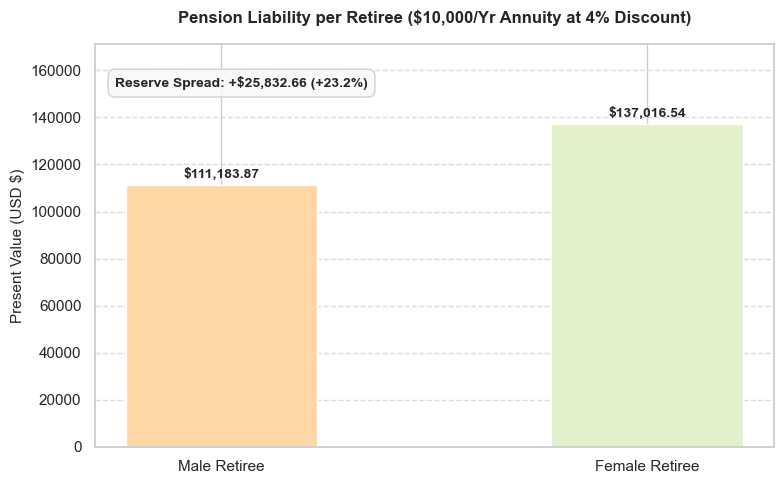

In [64]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5), dpi=100)
categories = ['Male Retiree', 'Female Retiree']
pv_values = [pv_male, pv_female]
colors = ['#FFD6A5', '#E2F0CB']
bars = ax.bar(categories, pv_values, color=colors, width=0.45)

# Labels
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + 2000, f'${yval:,.2f}', 
            ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_title('Pension Liability per Retiree ($10,000/Yr Annuity at 4% Discount)', 
             fontsize=12, fontweight='bold', pad=15)
ax.set_ylabel('Present Value (USD $)', fontsize=11)
ax.set_ylim(0, max(pv_values) * 1.25)  # Height padding for text & box
ax.grid(axis='y', linestyle='--', alpha=0.7)

ax.text(
    0.03, 0.92, 
    f'Reserve Spread: +${pv_diff:,.2f} (+{pct_increase:.1f}%)',
    transform=ax.transAxes,
    fontsize=10,
    fontweight='bold',
    verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='#f8f9fa', edgecolor='#cccccc', alpha=0.9)
)

plt.tight_layout()
plt.show()

#### Takeways:

Due to longer statistical life expectancies, female retirees carry a substantially higher present-value pension liability than male retirees.
Female retiree present value is 37,016.54 while for Male retiree present value it's 111,183.87.
Hence, an additional $25,832.66 (+23.2% increase) capital reserve surcharge is required for female retirees receiving a 10,000/year payout starting at age 65.